In [ ]:
# Project 3: Time Series Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
## Data preparation and visualization
def Data_Index(df):
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    df = df.set_index('DATE')
    return df


def Data_visualization(df):
    plt.figure(figsize=(12, 6))
    plt.title("Electric Production Over Time")
    plt.plot(df.index, df["IPG2211A2N"], linestyle="-")
    plt.xlabel("Date")
    plt.ylabel("Electric Production")
    plt.grid(True)
    plt.show()

In [3]:
## Feature engineering

def Make_Baseline_features(df):
    df = df.copy()
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    return df


def Make_Lag_features(df):
    df = df.copy()
    df["lag_1"] = df["IPG2211A2N"].shift(1)
    df["lag_2"] = df["IPG2211A2N"].shift(2)
    df["lag_3"] = df["IPG2211A2N"].shift(3)
    return df


def Rolling_means(df):
    df = df.copy()
    shifted_production = df["IPG2211A2N"].shift(1)
    df["rolling_mean_3"] = shifted_production.rolling(window=3, min_periods=1).mean()
    df["rolling_mean_6"] = shifted_production.rolling(window=6, min_periods=1).mean()
    return df


def add_exponential_smoothing(df):
    df = df.copy()
    shifted_production = df["IPG2211A2N"].shift(1)
    df["exponential_smoothing"] = shifted_production.ewm(span=3, adjust=False).mean()
    return df

In [4]:
## Load data and create features
df = pd.read_csv("Electric_Production.csv")

df = Data_Index(df)
df = Make_Baseline_features(df)
df = Make_Lag_features(df)
df = Rolling_means(df)
df = add_exponential_smoothing(df)

df = df.dropna()

df.head()

,IPG2211A2N,year,month,quarter,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6,exponential_smoothing
DATE,,,,,,,,,,
1985-04-01,57.4714,1985,4,2,62.4502,70.6720,72.5052,68.542467,68.542467,67.019400
1985-05-01,55.3151,1985,5,2,57.4714,62.4502,70.6720,63.531200,65.774700,62.245400
1985-06-01,58.0904,1985,6,2,55.3151,57.4714,62.4502,58.412233,63.682780,58.780250
1985-07-01,62.6202,1985,7,3,58.0904,55.3151,57.4714,56.958967,62.750717,58.435325
1985-08-01,63.2485,1985,8,3,62.6202,58.0904,55.3151,58.675233,61.103217,60.527763


In [5]:
## Anomaly detection and removal
from scipy import stats

z_scores = np.abs(stats.zscore(df["IPG2211A2N"]))
df = df[z_scores < 3]

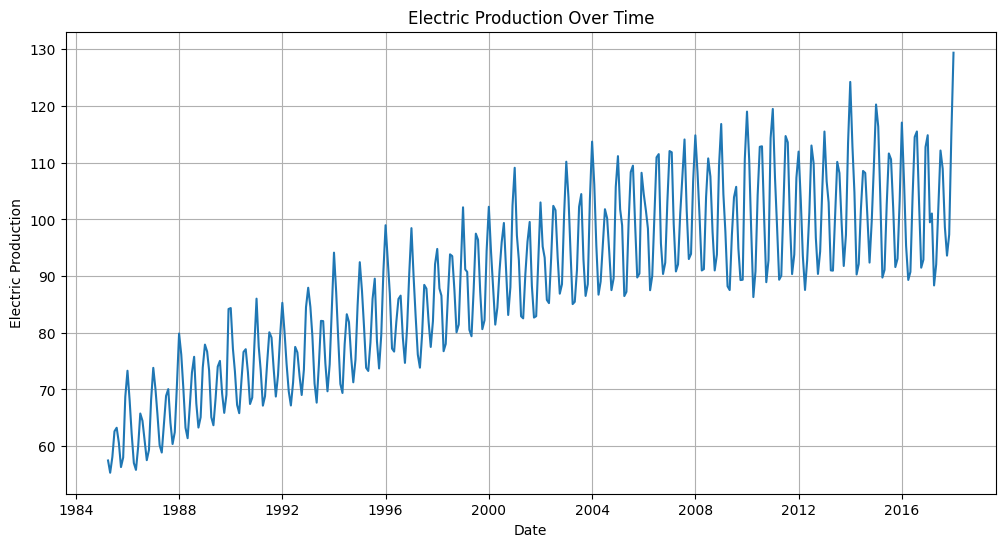

In [6]:
## Visualize the time series
Data_visualization(df)

In [7]:
## Train-test split and evaluation
def Train_test_split_function(df, target, features):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.8, shuffle=False
    )
    return X, y, X_train, X_test, y_train, y_test


def Evaluate_model_performance(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.2f}")

In [8]:
## XGBoost model
def XGBoost_Model():
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    return model

df_model = df.dropna().copy()

target = "IPG2211A2N"
features = [col for col in df_model.columns if col != target]

model = XGBoost_Model()
X, y, X_train, X_test, y_train, y_test = Train_test_split_function(df_model, target, features)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate_model_performance(y_test, y_pred)

MSE: 20.35
RMSE: 4.51
MAE: 3.40
R2: 0.78


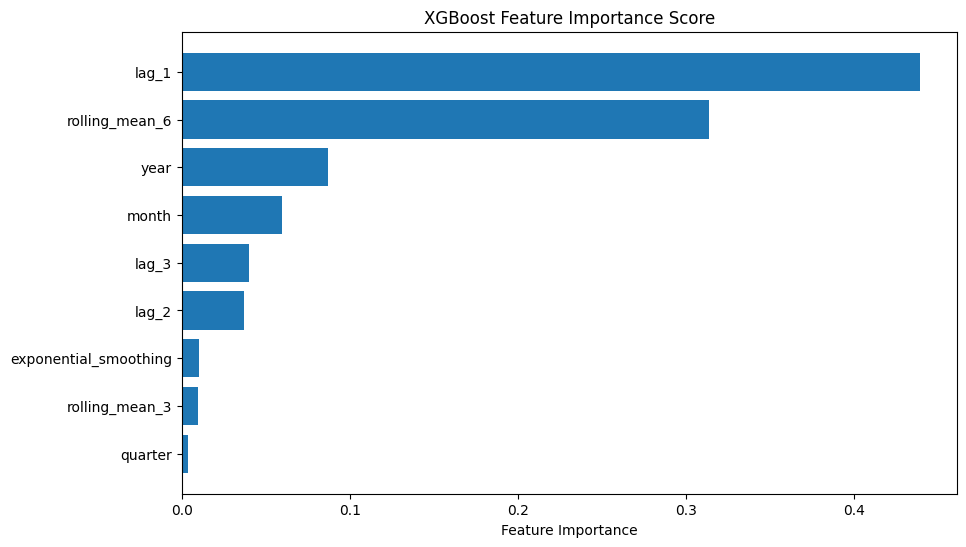

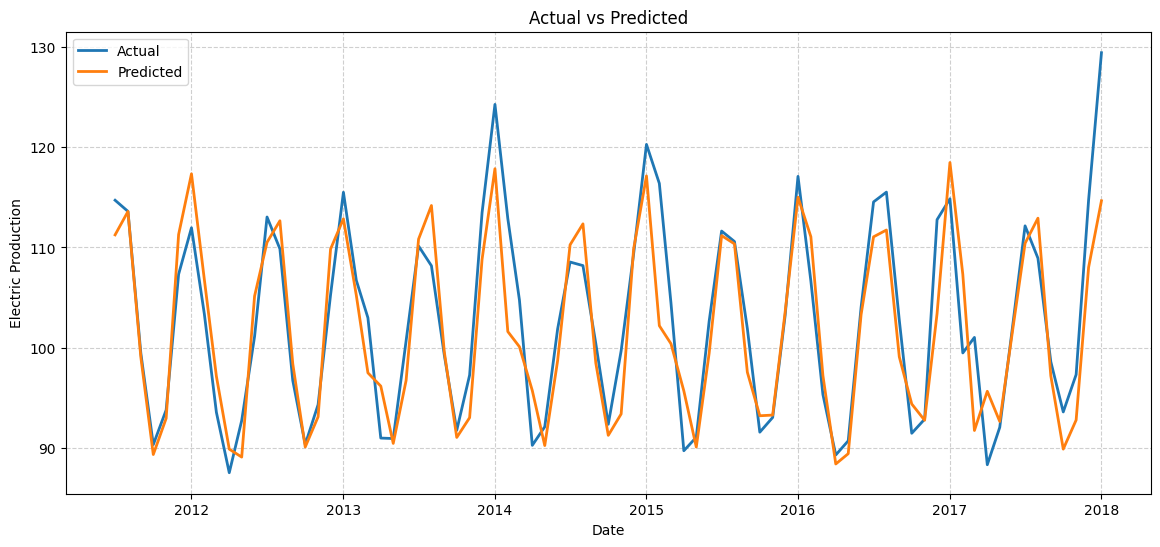

In [9]:
## XGBoost feature importance and prediction visualization
def XGBoost_Feature_importance(model, X):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": importance
    })
    feature_importance = feature_importance.sort_values(by="importance", ascending=False)
    return feature_importance


def Visualize_XGBoost_Feature_importance(feature_importance):
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance["feature"], feature_importance["importance"])
    plt.gca().invert_yaxis()
    plt.title("XGBoost Feature Importance Score")
    plt.xlabel("Feature Importance")
    plt.show()


def Actual_vs_Predicted_Visualize(y_test, y_pred, X_test):
    results = y_test.to_frame(name="actual").copy()
    results["predicted"] = y_pred
    results.index = X_test.index
    return results


def Visualize_Actual_vs_Predicted(results):
    plt.figure(figsize=(14, 6))
    plt.plot(results.index, results["actual"], label="Actual", linewidth=2)
    plt.plot(results.index, results["predicted"], label="Predicted", linewidth=2)
    plt.title("Actual vs Predicted")
    plt.xlabel("Date")
    plt.ylabel("Electric Production")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


feature_importance = XGBoost_Feature_importance(model, X_train)
Visualize_XGBoost_Feature_importance(feature_importance)

results = Actual_vs_Predicted_Visualize(y_test, y_pred, X_test)
Visualize_Actual_vs_Predicted(results)

In [10]:
## Random Forest model
def random_forest_model():
    return RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )

df_rf = df.dropna().copy()

target = "IPG2211A2N"
features = [c for c in df_rf.columns if c != target]

X, y, X_train, X_test, y_train, y_test = Train_test_split_function(df_rf, target, features)

model_rf = random_forest_model()
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print("Random Forest Results")
Evaluate_model_performance(y_test, y_pred_rf)

Random Forest Results
MSE: 23.28
RMSE: 4.82
MAE: 3.59
R2: 0.75


In [11]:
## Linear Regression model
def linear_regression_forecast():
    lr_model = LinearRegression()
    return lr_model

df_lr = df.dropna().copy()

target = "IPG2211A2N"
features = [col for col in df_lr.columns if col != target]

model_lr = linear_regression_forecast()
X, y, X_train, X_test, y_train, y_test = Train_test_split_function(df_lr, target, features)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
print("Linear Regression Results")
Evaluate_model_performance(y_test, y_pred_lr)

Linear Regression Results
MSE: 28.16
RMSE: 5.31
MAE: 4.53
R2: 0.70


In [12]:
## LSTM model

def split_data(df):
    split_index = int(len(df) * 0.8)
    train = df.iloc[:split_index]
    test = df.iloc[split_index:]
    return train, test


def create_dataset(dataset, time_steps=1):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        a = dataset[i:(i + time_steps), 0]
        X.append(a)
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)


def lstm_forecast(train, test):
    data_train = train["IPG2211A2N"].values.reshape(-1, 1)
    data_test = test["IPG2211A2N"].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    data_train_normalized = scaler.fit_transform(data_train)
    data_test_normalized = scaler.transform(data_test)

    time_steps = 3

    X_train, y_train = create_dataset(data_train_normalized, time_steps)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    lstm_model = Sequential()
    lstm_model.add(LSTM(units=50, input_shape=(X_train.shape[1], 1)))
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer="adam", loss="mean_squared_error")
    lstm_model.fit(X_train, y_train, epochs=5, batch_size=1, verbose=0)

    X_test, y_test = create_dataset(data_test_normalized, time_steps)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    lstm_predictions = lstm_model.predict(X_test, verbose=0)
    lstm_predictions = scaler.inverse_transform(lstm_predictions)

    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    lstm_mse = mean_squared_error(y_test_actual, lstm_predictions)
    lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
    lstm_rmse = np.sqrt(lstm_mse)
    lstm_r2 = r2_score(y_test_actual, lstm_predictions)

    print(f"MSE: {lstm_mse:.2f}")
    print(f"RMSE: {lstm_rmse:.2f}")
    print(f"MAE: {lstm_mae:.2f}")
    print(f"R2: {lstm_r2:.2f}")

    return lstm_model, y_test_actual, lstm_predictions

In [13]:
df_lstm = df.dropna().copy()
train, test = split_data(df_lstm)

lstm_model, y_test_actual, lstm_predictions = lstm_forecast(train, test)

/Users/rina/.pyenv/versions/3.10.4/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 91.26
RMSE: 9.55
MAE: 8.19
R2: 0.01
